In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/flights_sample.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (500000, 11)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE
0,2015,3,8,7,WN,MCI,MDW,1505,18.0,80.0,405
1,2015,5,3,7,WN,DAL,MCI,1735,10.0,85.0,460
2,2015,4,3,5,WN,RSW,CMH,1445,-4.0,150.0,930
3,2015,3,28,6,OO,GTF,DEN,1458,35.0,114.0,624
4,2015,9,6,7,WN,ATL,MCO,1635,-3.0,90.0,404


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 500000 non-null  int64  
 1   MONTH                500000 non-null  int64  
 2   DAY                  500000 non-null  int64  
 3   DAY_OF_WEEK          500000 non-null  int64  
 4   AIRLINE              500000 non-null  object 
 5   ORIGIN_AIRPORT       500000 non-null  object 
 6   DESTINATION_AIRPORT  500000 non-null  object 
 7   SCHEDULED_DEPARTURE  500000 non-null  int64  
 8   DEPARTURE_DELAY      500000 non-null  float64
 9   SCHEDULED_TIME       499999 non-null  float64
 10  DISTANCE             500000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 42.0+ MB


In [3]:
df.isnull().sum()

YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_DELAY        0
SCHEDULED_TIME         1
DISTANCE               0
dtype: int64

In [4]:
df.describe()


,YEAR,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE
count,500000.0,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499999.000000,500000.000000
mean,2015.0,5.693678,15.449040,3.949090,1328.613582,9.319698,141.583593,823.526862
std,0.0,2.928288,8.852357,1.984026,482.521400,36.494963,75.300293,609.487759
min,2015.0,1.000000,1.000000,1.000000,3.000000,-68.000000,18.000000,31.000000
25%,2015.0,3.000000,8.000000,2.000000,917.000000,-5.000000,85.000000,373.000000
50%,2015.0,6.000000,15.000000,4.000000,1325.000000,-2.000000,122.000000,647.000000
75%,2015.0,8.000000,23.000000,6.000000,1730.000000,7.000000,173.000000,1065.000000
max,2015.0,11.000000,31.000000,7.000000,2359.000000,1475.000000,718.000000,4983.000000


In [6]:
df["DELAYED"] = (df["DEPARTURE_DELAY"] >= 15).astype(int)
df["DELAYED"].value_counts()
df["DELAYED"].value_counts(normalize=True) * 100

DELAYED
0    81.5452
1    18.4548
Name: proportion, dtype: float64

In [10]:
df.isnull().sum().sort_values(ascending=False)

SCHEDULED_TIME         1
YEAR                   0
DAY                    0
MONTH                  0
DAY_OF_WEEK            0
AIRLINE                0
DESTINATION_AIRPORT    0
ORIGIN_AIRPORT         0
SCHEDULED_DEPARTURE    0
DEPARTURE_DELAY        0
DISTANCE               0
DELAYED                0
dtype: int64

In [9]:
df = df.dropna(subset=["DEPARTURE_DELAY"])
print(df.shape)

(500000, 12)


In [11]:
df["SCHEDULED_DEPARTURE"] = (
    df["SCHEDULED_DEPARTURE"]
    .astype(str)
    .str.zfill(4)
)

df["DEPARTURE_HOUR"] = (
    df["SCHEDULED_DEPARTURE"]
    .str[:2]
    .astype(int)
)


In [12]:
df[[
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_HOUR"
]].head(10)

,SCHEDULED_DEPARTURE,DEPARTURE_HOUR
0,1505,15
1,1735,17
2,1445,14
3,1458,14
4,1635,16
5,0600,6
6,0620,6
7,0843,8
8,1958,19
9,0915,9


In [13]:
df["DEPARTURE_HOUR"].value_counts().sort_index()

DEPARTURE_HOUR
0      1211
1       427
2       138
3        59
4        40
5      9929
6     34931
7     33978
8     32793
9     30419
10    32041
11    30946
12    30486
13    31383
14    27974
15    32132
16    28774
17    33647
18    28510
19    28492
20    22195
21    15932
22     9943
23     3620
Name: count, dtype: int64

In [14]:
df["DEPARTURE_HOUR"].min(), df["DEPARTURE_HOUR"].max()

(np.int64(0), np.int64(23))

In [15]:
df["IS_WEEKEND"] = (
    df["DAY_OF_WEEK"].isin([6, 7])
).astype(int)

In [16]:
df["DISTANCE_CATEGORY"] = pd.cut(
    df["DISTANCE"],
    bins=[0, 500, 1000, 2000, np.inf],
    labels=["Short", "Medium", "Long", "Very Long"]
)

In [17]:
df[[
    "DISTANCE",
    "DISTANCE_CATEGORY",
    "IS_WEEKEND"
]].head()

,DISTANCE,DISTANCE_CATEGORY,IS_WEEKEND
0,405,Short,1
1,460,Short,1
2,930,Medium,0
3,624,Medium,1
4,404,Short,1


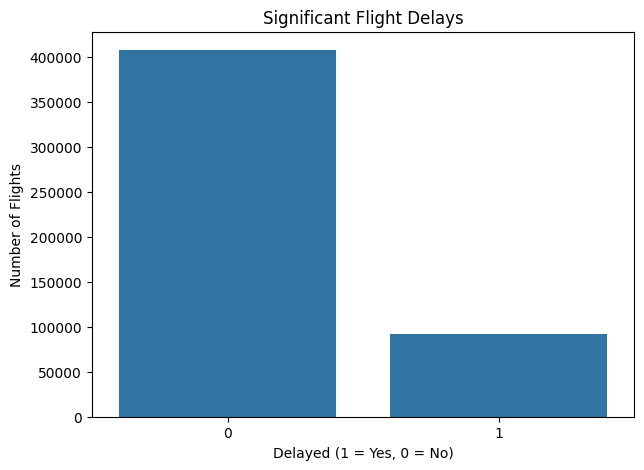

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="DELAYED"
)

plt.title("Significant Flight Delays")
plt.xlabel("Delayed (1 = Yes, 0 = No)")
plt.ylabel("Number of Flights")

plt.show()

In [19]:
airline_delay = (
    df.groupby("AIRLINE")["DELAYED"]
    .mean()
    .sort_values(ascending=False)
)

print(airline_delay)

AIRLINE
NK    0.273137
UA    0.241345
F9    0.224463
B6    0.216562
WN    0.210979
MQ    0.206381
AA    0.177628
EV    0.176751
OO    0.162597
VX    0.160235
US    0.148467
DL    0.142488
AS    0.104287
HA    0.076303
Name: DELAYED, dtype: float64


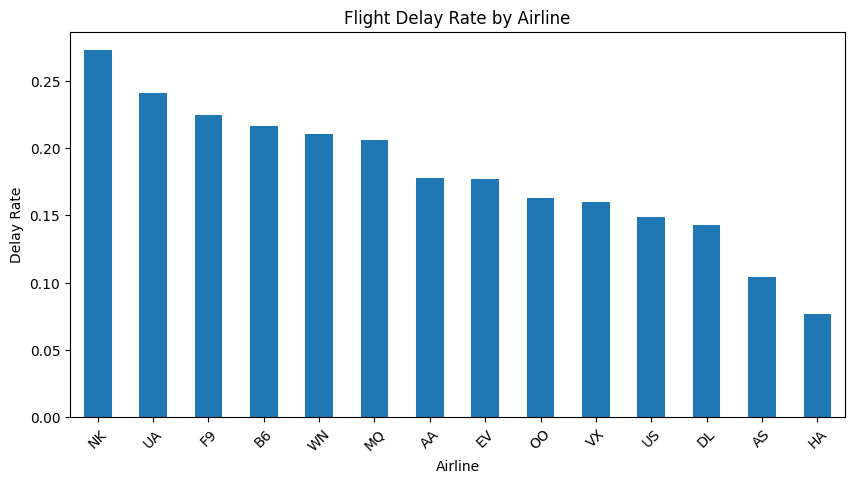

In [20]:
plt.figure(figsize=(10, 5))

airline_delay.plot(kind="bar")

plt.title("Flight Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Rate")

plt.xticks(rotation=45)

plt.show()

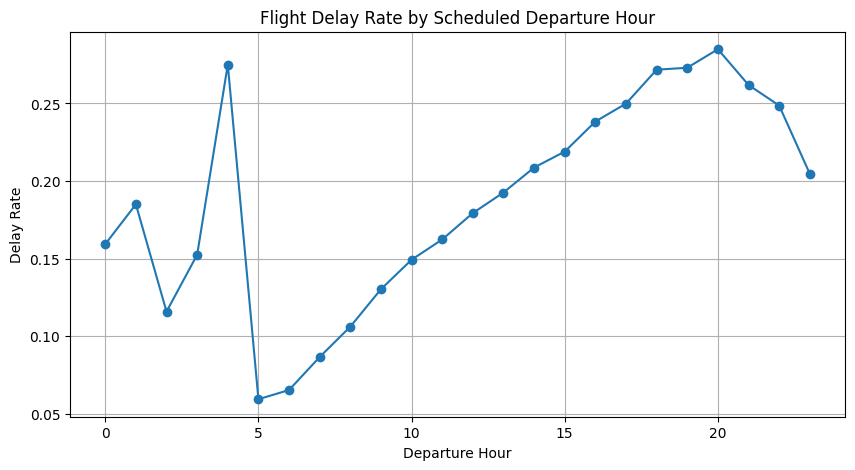

In [21]:
hour_delay = (
    df.groupby("DEPARTURE_HOUR")["DELAYED"]
    .mean()
)

plt.figure(figsize=(10, 5))

hour_delay.plot(marker="o")

plt.title("Flight Delay Rate by Scheduled Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate")

plt.grid(True)

plt.show()

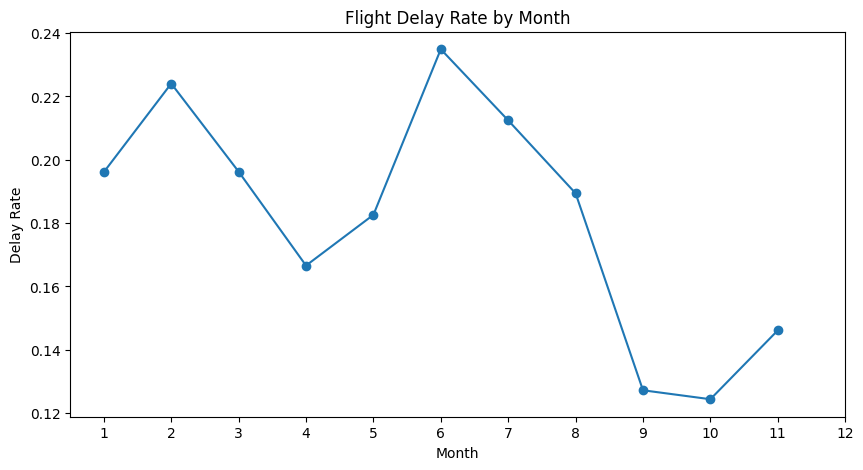

In [22]:
month_delay = (
    df.groupby("MONTH")["DELAYED"]
    .mean()
)

plt.figure(figsize=(10, 5))

month_delay.plot(marker="o")

plt.title("Flight Delay Rate by Month")
plt.xlabel("Month")
plt.ylabel("Delay Rate")

plt.xticks(range(1, 13))

plt.show()

In [23]:
origin_delay = (
    df.groupby("ORIGIN_AIRPORT")["DELAYED"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

origin_delay.head(15)


,mean,count
ORIGIN_AIRPORT,,
15497,1.000000,1
10165,1.000000,1
ILG,0.600000,5
10551,0.600000,5
ADK,0.571429,7
14256,0.500000,8
13964,0.500000,4
GUM,0.370370,27
GST,0.363636,11


In [24]:
major_origins = origin_delay[
    origin_delay["count"] >= 500
]

major_origins.head(10)

,mean,count
ORIGIN_AIRPORT,,
ORD,0.257142,23839
BWI,0.254326,7282
MDW,0.253187,6746
HOU,0.252160,4398
MIA,0.238151,5929
EWR,0.232636,8610
LGA,0.231949,8213
DAL,0.231420,5086
DFW,0.228770,20278


In [25]:
clean_columns = [
    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "IS_WEEKEND",
    "DELAYED"
]

clean_df = df[clean_columns].copy()

clean_df.to_csv(
    "../data/cleaned_flights.csv",
    index=False
)

print("Saved:", clean_df.shape)

Saved: (500000, 13)


In [26]:
clean_df.isnull().sum()

YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_HOUR         0
SCHEDULED_TIME         1
DISTANCE               0
IS_WEEKEND             0
DELAYED                0
dtype: int64

In [27]:
clean_df = clean_df.dropna()

In [28]:
print(clean_df.shape)
print(clean_df.isnull().sum().sum())

(499999, 13)
0


In [29]:
clean_df.to_csv(
    "../data/cleaned_flights.csv",
    index=False
)